# Brand Shopping Agent Executive Showcase (API-First Personalization)

### Why
Leaders need evidence that one product can drive different business outcomes based on customer intent, not static PDP defaults.
This notebook demonstrates how an API-first shopping agent personalizes price, shipping, warranty, and financing per customer profile.

### How
A strict API client orchestrates a staged flow: product retrieval, customer profile retrieval, candidate offer generation, ranking, and explainable recommendation payloads.
Each stage emits structured events so decisions can be monitored and audited.

### What
You will see the same camera SKU produce different response payloads for speed-first and cost-first customers.
The run ends with monitoring charts that connect personalization behavior to operational and business signals.

### Measurable Signal
Clear divergence in recommendation attributes for the same SKU, with traceable API events and stage-level performance summaries.

## Stage 0 - Runtime Contract

### Why
A runtime contract prevents personalization drift and makes recommendation behavior defensible for product, legal, and operations stakeholders.

### How
We define explicit API contracts for catalog lookup, profile lookup, offer generation, ranking, and response composition.
The flow enforces deterministic guardrails before any recommendation is emitted.

### What
A shared contract for request and response structures, pricing boundaries, and event lineage.

### Measurable Signal
Consistent response schema and reproducible ranking results for repeated runs with identical inputs.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from datetime import datetime, timezone
from itertools import product as cartesian_product
from typing import Any
import json
import time
from uuid import uuid4

@dataclass(frozen=True)
class Product:
    sku: str
    name: str
    list_price: float
    min_price: float

@dataclass(frozen=True)
class CustomerProfile:
    customer_id: str
    display_name: str
    speed_weight: float
    protection_weight: float
    total_cost_weight: float
    monthly_payment_weight: float
    max_monthly_payment: float

PRODUCTS_DB = {
    "HD-CAM-X": Product(
        sku="HD-CAM-X",
        name="HD Digital Camera Model X",
        list_price=699.0,
        min_price=659.0,
    )
}

CUSTOMERS_DB = {
    "cust-speed": CustomerProfile(
        customer_id="cust-speed",
        display_name="Customer A (speed + protection)",
        speed_weight=0.45,
        protection_weight=0.35,
        total_cost_weight=0.10,
        monthly_payment_weight=0.10,
        max_monthly_payment=800.0,
    ),
    "cust-cost": CustomerProfile(
        customer_id="cust-cost",
        display_name="Customer B (cost + cash flow)",
        speed_weight=0.05,
        protection_weight=0.10,
        total_cost_weight=0.45,
        monthly_payment_weight=0.40,
        max_monthly_payment=65.0,
    ),
    "cust-balanced": CustomerProfile(
        customer_id="cust-balanced",
        display_name="Customer C (balanced)",
        speed_weight=0.25,
        protection_weight=0.20,
        total_cost_weight=0.30,
        monthly_payment_weight=0.25,
        max_monthly_payment=220.0,
    ),
}

SHIPPING_OPTIONS = [
    {"name": "Express", "days": 1, "cost": 19.0},
    {"name": "Standard", "days": 3, "cost": 0.0},
    {"name": "Economy", "days": 5, "cost": -8.0},
]

WARRANTY_OPTIONS = [
    {"years": 0, "cost": 0.0},
    {"years": 2, "cost": 79.0},
]

FINANCING_OPTIONS = [
    {"months": 1, "apr": 0.0},
    {"months": 12, "apr": 0.0},
]

MAX_DISCOUNT = 0.06
RUN_ID = str(uuid4())
EVENT_TIMELINE: list[dict[str, Any]] = []

def stage(title: str) -> None:
    print("\n" + "=" * 96)
    print(title)
    print("=" * 96)

def append_event(
    event_type: str,
    *,
    stage_name: str,
    decision: str,
    reason: str,
    entity_id: str,
    actor: str = "brand-shopping-agent",
    quality: dict[str, Any] | None = None,
) -> None:
    EVENT_TIMELINE.append(
        {
            "event_id": str(uuid4()),
            "timestamp": datetime.now(timezone.utc).isoformat(),
            "run_id": RUN_ID,
            "event_type": event_type,
            "stage": stage_name,
            "actor": actor,
            "entity_id": entity_id,
            "decision": decision,
            "reason": reason,
            "quality": quality or {},
        }
    )

def _normalize_speed(days: int) -> float:
    return max(0.0, min(1.0, (5 - days) / 4))

def _normalize_protection(years: int) -> float:
    return max(0.0, min(1.0, years / 2))

def _normalize_total_cost(total_cost: float, item: Product) -> float:
    worst = item.list_price + 180
    best = item.min_price
    return max(0.0, min(1.0, (worst - total_cost) / (worst - best)))

def _normalize_monthly(payment: float) -> float:
    worst = 800.0
    return max(0.0, min(1.0, (worst - payment) / worst))

def _candidate_price(item: Product, profile: CustomerProfile) -> float:
    if profile.total_cost_weight >= 0.4:
        return round(max(item.list_price * (1 - MAX_DISCOUNT), item.min_price), 2)
    return item.list_price

def _monthly_payment(total: float, months: int) -> float:
    return round(total / months, 2)

def _api_get_product(path_params: dict[str, str], _: dict[str, Any] | None) -> dict[str, Any]:
    sku = path_params["sku"]
    if sku not in PRODUCTS_DB:
        return {"status": 404, "body": {"error": f"SKU {sku} not found"}}
    item = PRODUCTS_DB[sku]
    return {"status": 200, "body": item.__dict__}

def _api_get_profile(path_params: dict[str, str], _: dict[str, Any] | None) -> dict[str, Any]:
    customer_id = path_params["customer_id"]
    if customer_id not in CUSTOMERS_DB:
        return {"status": 404, "body": {"error": f"Customer {customer_id} not found"}}
    profile = CUSTOMERS_DB[customer_id]
    return {"status": 200, "body": profile.__dict__}

def _api_generate_offers(_: dict[str, str], body: dict[str, Any] | None) -> dict[str, Any]:
    payload = body or {}
    sku = str(payload.get("sku", ""))
    customer_id = str(payload.get("customer_id", ""))
    if sku not in PRODUCTS_DB or customer_id not in CUSTOMERS_DB:
        return {"status": 400, "body": {"error": "sku/customer_id missing or invalid"}}

    item = PRODUCTS_DB[sku]
    profile = CUSTOMERS_DB[customer_id]
    unit_price = _candidate_price(item, profile)

    offers: list[dict[str, Any]] = []
    for shipping, warranty, financing in cartesian_product(
        SHIPPING_OPTIONS, WARRANTY_OPTIONS, FINANCING_OPTIONS
    ):
        total = round(unit_price + shipping["cost"] + warranty["cost"], 2)
        monthly = _monthly_payment(total, financing["months"])
        if monthly > profile.max_monthly_payment:
            continue
        offers.append(
            {
                "sku": sku,
                "customer_id": customer_id,
                "price": unit_price,
                "shipping_name": shipping["name"],
                "shipping_days": shipping["days"],
                "warranty_years": warranty["years"],
                "financing_months": financing["months"],
                "total_cost": total,
                "monthly_payment": monthly,
            }
        )

    return {"status": 200, "body": {"offers": offers}}

def _api_rank_offers(_: dict[str, str], body: dict[str, Any] | None) -> dict[str, Any]:
    payload = body or {}
    offers = payload.get("offers") or []
    customer_id = str(payload.get("customer_id", ""))
    sku = str(payload.get("sku", ""))

    if customer_id not in CUSTOMERS_DB or sku not in PRODUCTS_DB:
        return {"status": 400, "body": {"error": "sku/customer_id missing or invalid"}}

    profile = CUSTOMERS_DB[customer_id]
    item = PRODUCTS_DB[sku]

    scored: list[dict[str, Any]] = []
    for offer in offers:
        s_speed = _normalize_speed(int(offer["shipping_days"]))
        s_prot = _normalize_protection(int(offer["warranty_years"]))
        s_cost = _normalize_total_cost(float(offer["total_cost"]), item)
        s_monthly = _normalize_monthly(float(offer["monthly_payment"]))
        score = (
            profile.speed_weight * s_speed
            + profile.protection_weight * s_prot
            + profile.total_cost_weight * s_cost
            + profile.monthly_payment_weight * s_monthly
        )
        enriched = dict(offer)
        enriched["score"] = round(score, 4)
        enriched["score_breakdown"] = {
            "speed": round(s_speed, 4),
            "protection": round(s_prot, 4),
            "total_cost": round(s_cost, 4),
            "monthly_payment": round(s_monthly, 4),
        }
        scored.append(enriched)

    ranked = sorted(scored, key=lambda x: x["score"], reverse=True)
    return {"status": 200, "body": {"offers": ranked}}

def _api_compose_response(_: dict[str, str], body: dict[str, Any] | None) -> dict[str, Any]:
    payload = body or {}
    customer_id = str(payload.get("customer_id", ""))
    sku = str(payload.get("sku", ""))
    offers = payload.get("offers") or []
    if customer_id not in CUSTOMERS_DB or sku not in PRODUCTS_DB or not offers:
        return {"status": 400, "body": {"error": "Unable to compose payload"}}

    profile = CUSTOMERS_DB[customer_id]
    top = offers[0]
    hero_message = (
        f"{profile.display_name}: {PRODUCTS_DB[sku].name} with {top['shipping_name']} shipping, "
        f"{top['warranty_years']}y protection, and ${top['monthly_payment']:.2f}/month."
    )

    return {
        "status": 200,
        "body": {
            "customer_id": customer_id,
            "customer_name": profile.display_name,
            "sku": sku,
            "hero_message": hero_message,
            "top_offer": top,
            "alternatives": offers[1:3],
            "decision_reason": "Offer ranked highest for this profile's weighted priorities.",
        },
    }

ROUTES: dict[tuple[str, str], Any] = {
    ("GET", "/catalog/products/{sku}"): _api_get_product,
    ("GET", "/customers/{customer_id}/profile"): _api_get_profile,
    ("POST", "/pricing/offers"): _api_generate_offers,
    ("POST", "/recommendations/rank"): _api_rank_offers,
    ("POST", "/recommendations/compose"): _api_compose_response,
}

def _match_route(method: str, path: str) -> tuple[Any, dict[str, str]]:
    for (route_method, pattern), handler in ROUTES.items():
        if route_method != method:
            continue
        pattern_parts = pattern.strip("/").split("/")
        path_parts = path.strip("/").split("/")
        if len(pattern_parts) != len(path_parts):
            continue

        params: dict[str, str] = {}
        matched = True
        for pp, cp in zip(pattern_parts, path_parts):
            if pp.startswith("{") and pp.endswith("}"):
                params[pp[1:-1]] = cp
            elif pp != cp:
                matched = False
                break
        if matched:
            return handler, params
    raise RuntimeError(f"No route matched for {method} {path}")

def strict_api_call(method: str, path: str, body: dict[str, Any] | None = None) -> dict[str, Any]:
    method_u = method.upper()
    started_at = time.perf_counter()
    handler, params = _match_route(method_u, path)
    response = handler(params, body)
    elapsed_ms = round((time.perf_counter() - started_at) * 1000, 3)

    status = int(response.get("status", 500))
    parsed = response.get("body", {})
    if status >= 400:
        raise RuntimeError(f"API error {status} for {method_u} {path}: {json.dumps(parsed)}")

    append_event(
        "api.call",
        stage_name="api_gateway",
        decision="ok",
        reason=f"{method_u} {path}",
        entity_id=str((body or {}).get("sku") or params.get("sku") or "platform"),
        actor="strict_api_client",
        quality={"status": status, "latency_ms": elapsed_ms},
    )
    return {"status": status, "body": parsed, "latency_ms": elapsed_ms}

print("Runtime contract loaded.")
print(f"Run id: {RUN_ID}")

Runtime contract loaded.
Run id: f1c8cc86-e2b9-4436-8442-eabbd0b63cb5


In [ ]:
## Stage 1-4 - End-to-End API Personalization Flow

### Why
The system must prove that the same product yields different decision-ready payloads when customer priorities differ.

### How
Each customer run uses the same SKU and traverses the same API chain: product -> profile -> offers -> ranking -> response composition.

### What
The result is a profile-specific recommendation object with a different hero message, top offer, and trade-off rationale per customer.

### Measurable Signal
Divergent top-offer attributes for the same SKU across customer IDs, with complete event lineage.

In [2]:
stage("STAGE 1 - PRODUCT LOOKUP")
product_resp = strict_api_call("GET", "/catalog/products/HD-CAM-X")
product_view = product_resp["body"]
append_event(
    "stage.transition",
    stage_name="stage_1_product",
    decision="loaded",
    reason="Product retrieved via catalog API.",
    entity_id=product_view["sku"],
)
print(json.dumps(product_view, indent=2))

stage("STAGE 2 - CUSTOMER PROFILE LOOKUP")
customer_ids = ["cust-speed", "cust-cost", "cust-balanced"]
customer_profiles = []
for customer_id in customer_ids:
    profile_resp = strict_api_call("GET", f"/customers/{customer_id}/profile")
    customer_profiles.append(profile_resp["body"])

append_event(
    "stage.transition",
    stage_name="stage_2_profiles",
    decision="loaded",
    reason="Customer profiles retrieved for personalization run.",
    entity_id=product_view["sku"],
    quality={"customer_count": len(customer_profiles)},
)
print(json.dumps(customer_profiles, indent=2))

stage("STAGE 3 - OFFER GENERATION AND RANKING")
ranked_offers_by_customer: dict[str, list[dict[str, Any]]] = {}
api_latency_records: list[dict[str, Any]] = []

for profile in customer_profiles:
    customer_id = profile["customer_id"]

    offers_resp = strict_api_call(
        "POST",
        "/pricing/offers",
        {"sku": product_view["sku"], "customer_id": customer_id},
    )
    ranked_resp = strict_api_call(
        "POST",
        "/recommendations/rank",
        {
            "sku": product_view["sku"],
            "customer_id": customer_id,
            "offers": offers_resp["body"]["offers"],
        },
    )

    ranked_offers_by_customer[customer_id] = ranked_resp["body"]["offers"]

    api_latency_records.extend(
        [
            {"customer_id": customer_id, "endpoint": "/pricing/offers", "latency_ms": offers_resp["latency_ms"]},
            {"customer_id": customer_id, "endpoint": "/recommendations/rank", "latency_ms": ranked_resp["latency_ms"]},
        ]
    )

append_event(
    "stage.transition",
    stage_name="stage_3_rank",
    decision="scored",
    reason="Offers generated and ranked for each customer profile.",
    entity_id=product_view["sku"],
    quality={
        "customers": len(ranked_offers_by_customer),
        "max_offer_set": max(len(v) for v in ranked_offers_by_customer.values()),
    },
)

stage("STAGE 4 - RESPONSE COMPOSITION")
personalized_payloads: dict[str, dict[str, Any]] = {}
for customer_id, ranked_offers in ranked_offers_by_customer.items():
    compose_resp = strict_api_call(
        "POST",
        "/recommendations/compose",
        {
            "sku": product_view["sku"],
            "customer_id": customer_id,
            "offers": ranked_offers,
        },
    )
    personalized_payloads[customer_id] = compose_resp["body"]
    api_latency_records.append(
        {"customer_id": customer_id, "endpoint": "/recommendations/compose", "latency_ms": compose_resp["latency_ms"]}
    )

append_event(
    "stage.transition",
    stage_name="stage_4_compose",
    decision="personalized",
    reason="Built customer-specific recommendation payloads for the same product.",
    entity_id=product_view["sku"],
)

comparison_view = []
for customer_id, payload in personalized_payloads.items():
    top = payload["top_offer"]
    comparison_view.append(
        {
            "customer": payload["customer_name"],
            "sku": payload["sku"],
            "shipping": f"{top['shipping_name']} ({top['shipping_days']}d)",
            "warranty_years": top["warranty_years"],
            "financing_months": top["financing_months"],
            "total_cost": top["total_cost"],
            "monthly_payment": top["monthly_payment"],
            "score": top["score"],
            "hero_message": payload["hero_message"],
        }
    )

print("Same product, different payloads by customer profile:")
print(json.dumps(comparison_view, indent=2))


STAGE 1 - PRODUCT LOOKUP
{
  "sku": "HD-CAM-X",
  "name": "HD Digital Camera Model X",
  "list_price": 699.0,
  "min_price": 659.0
}

STAGE 2 - CUSTOMER PROFILE LOOKUP
[
  {
    "customer_id": "cust-speed",
    "display_name": "Customer A (speed + protection)",
    "speed_weight": 0.45,
    "protection_weight": 0.35,
    "total_cost_weight": 0.1,
    "monthly_payment_weight": 0.1,
    "max_monthly_payment": 800.0
  },
  {
    "customer_id": "cust-cost",
    "display_name": "Customer B (cost + cash flow)",
    "speed_weight": 0.05,
    "protection_weight": 0.1,
    "total_cost_weight": 0.45,
    "monthly_payment_weight": 0.4,
    "max_monthly_payment": 65.0
  },
  {
    "customer_id": "cust-balanced",
    "display_name": "Customer C (balanced)",
    "speed_weight": 0.25,
    "protection_weight": 0.2,
    "total_cost_weight": 0.3,
    "monthly_payment_weight": 0.25,
    "max_monthly_payment": 220.0
  }
]

STAGE 3 - OFFER GENERATION AND RANKING

STAGE 4 - RESPONSE COMPOSITION
Same produc

In [ ]:
## Stage 5 - Monitoring Dataset Preparation

### Why
Personalization needs observability so teams can verify behavior, latency, and business alignment.

### How
We convert recommendation payloads and API events into analysis tables for operational and executive charts.

### What
A monitoring-ready dataset with customer-level outcomes, endpoint latency, and stage transition counts.

### Measurable Signal
Clear, queryable evidence that customer priorities materially change recommendation outputs for one SKU.

In [3]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

try:
    import seaborn as sns
except Exception as ex:  # pragma: no cover - notebook guard
    sns = None
    warnings.warn(f"Seaborn unavailable; falling back to matplotlib only. Details: {ex}")

if sns is not None:
    sns.set_theme(style="whitegrid", context="notebook")

recommendation_rows = []
for payload in personalized_payloads.values():
    top = payload["top_offer"]
    recommendation_rows.append(
        {
            "customer": payload["customer_name"],
            "sku": payload["sku"],
            "shipping_days": top["shipping_days"],
            "warranty_years": top["warranty_years"],
            "financing_months": top["financing_months"],
            "total_cost": top["total_cost"],
            "monthly_payment": top["monthly_payment"],
            "score": top["score"],
        }
    )

recommendations_df = pd.DataFrame(recommendation_rows)
latency_df = pd.DataFrame(api_latency_records)
events_df = pd.DataFrame(EVENT_TIMELINE)

if events_df.empty:
    stage_counts_df = pd.DataFrame(columns=["stage", "count"])
else:
    stage_counts_df = (
        events_df.groupby("stage", dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

print("Monitoring datasets prepared:")
print(f"- recommendations rows: {len(recommendations_df)}")
print(f"- latency rows: {len(latency_df)}")
print(f"- event rows: {len(events_df)}")
display(recommendations_df)

Monitoring datasets prepared:
- recommendations rows: 3
- latency rows: 9
- event rows: 17


,customer,sku,shipping_days,warranty_years,financing_months,total_cost,monthly_payment,score
0,Customer A (speed + protection),HD-CAM-X,1,2,12,797.0,66.42,0.9290
1,Customer B (cost + cash flow),HD-CAM-X,3,0,12,659.0,54.92,0.8475
2,Customer C (balanced),HD-CAM-X,1,2,12,797.0,66.42,0.7911


## Stage 6 - Monitoring Graphs and Executive Snapshot

### Why
Business stakeholders need a clear visual proof that personalization changed outcomes for the same product.

### How
The final chart suite visualizes customer-level economics, API latency, and stage-event density from this run.

### What
A compact operational and executive view that can be used in demos, governance reviews, and architecture discussions.

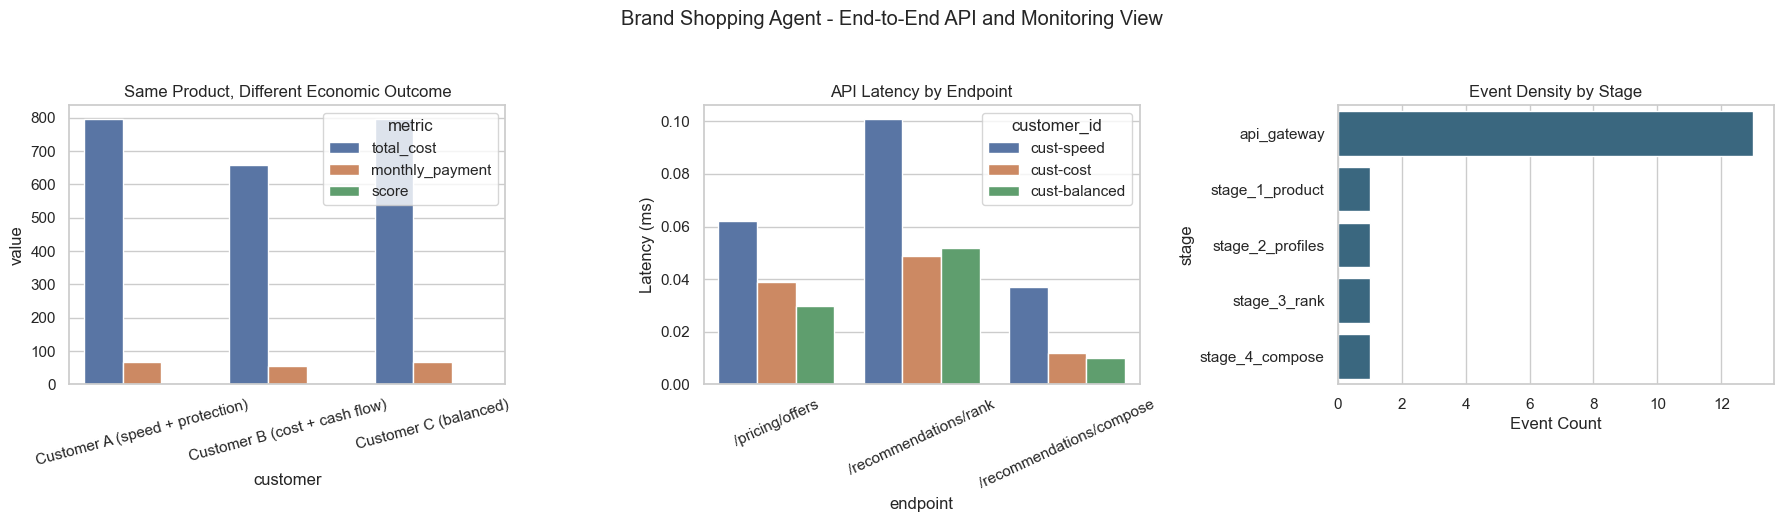

Executive snapshot:
{
  "run_id": "f1c8cc86-e2b9-4436-8442-eabbd0b63cb5",
  "sku": "HD-CAM-X",
  "customer_count": 3,
  "top_shipping_mix": {
    "1": 2,
    "3": 1
  },
  "avg_total_cost": 751.0,
  "avg_monthly_payment": 62.59,
  "event_count": 17
}


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Same SKU, different economics per customer.
if recommendations_df.empty:
    axes[0].text(0.5, 0.5, "No recommendation data", ha="center", va="center")
    axes[0].axis("off")
else:
    melt_df = recommendations_df.melt(
        id_vars=["customer"],
        value_vars=["total_cost", "monthly_payment", "score"],
        var_name="metric",
        value_name="value",
    )
    if sns is not None:
        sns.barplot(data=melt_df, x="customer", y="value", hue="metric", ax=axes[0])
    else:
        for metric in ["total_cost", "monthly_payment", "score"]:
            subset = melt_df[melt_df["metric"] == metric]
            axes[0].bar(subset["customer"], subset["value"], alpha=0.6, label=metric)
    axes[0].set_title("Same Product, Different Economic Outcome")
    axes[0].tick_params(axis="x", rotation=15)

# Chart 2: API latency by endpoint and customer.
if latency_df.empty:
    axes[1].text(0.5, 0.5, "No latency data", ha="center", va="center")
    axes[1].axis("off")
else:
    if sns is not None:
        sns.barplot(data=latency_df, x="endpoint", y="latency_ms", hue="customer_id", ax=axes[1])
    else:
        for customer_id in sorted(latency_df["customer_id"].unique()):
            subset = latency_df[latency_df["customer_id"] == customer_id]
            axes[1].plot(subset["endpoint"], subset["latency_ms"], marker="o", label=customer_id)
    axes[1].set_title("API Latency by Endpoint")
    axes[1].tick_params(axis="x", rotation=25)
    axes[1].set_ylabel("Latency (ms)")

# Chart 3: Event timeline density by stage.
if stage_counts_df.empty:
    axes[2].text(0.5, 0.5, "No event timeline data", ha="center", va="center")
    axes[2].axis("off")
else:
    if sns is not None:
        sns.barplot(data=stage_counts_df, x="count", y="stage", ax=axes[2], color="#2F6B8A")
    else:
        axes[2].barh(stage_counts_df["stage"], stage_counts_df["count"], color="#2F6B8A")
    axes[2].set_title("Event Density by Stage")
    axes[2].set_xlabel("Event Count")

fig.suptitle("Brand Shopping Agent - End-to-End API and Monitoring View", y=1.04)
fig.tight_layout()
plt.show()

executive_snapshot = {
    "run_id": RUN_ID,
    "sku": product_view["sku"],
    "customer_count": len(recommendations_df),
    "top_shipping_mix": recommendations_df["shipping_days"].value_counts().to_dict() if not recommendations_df.empty else {},
    "avg_total_cost": round(float(recommendations_df["total_cost"].mean()), 2) if not recommendations_df.empty else None,
    "avg_monthly_payment": round(float(recommendations_df["monthly_payment"].mean()), 2) if not recommendations_df.empty else None,
    "event_count": len(EVENT_TIMELINE),
}

print("Executive snapshot:")
print(json.dumps(executive_snapshot, indent=2))